# Basic FEW + SuperKludge tutorial

This notebook covers the minimum you need from the [FastEMRIWaveforms (FEW)](https://bhptoolkit.org/FastEMRIWaveforms/) package to work with the **SuperKludge** model in this repository:

1. the waveform-generator interface and the EMRI parameters it takes,
2. the flux models (the 0PA `KerrEccEqFlux` and the hybrid `SuperKludgeFlux`), including the extra SuperKludge arguments,
3. computing trajectories with `EMRIInspiral`, choosing $p_0$ with `get_p_at_t`, and checking the plunge with `get_separatrix`,
4. generating waveforms with `GenerateEMRIWaveform(SuperKludgeWaveform, ...)`.

Most of this is already in the official FEW documentation. It is repeated here for completeness, with the SuperKludge-specific parts added.

Follow-up notebooks in this folder: `deviation_models.ipynb`.

> **Install note:** this notebook must import `few` from **this** repository (`SuperKludge_r/src`) and use `hybrid` branch. Otherwise the deviation arguments in Section 3 are silently ignored. The next cell prints the path it imported from.

## 0. Setup

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

import few
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux, SuperKludgeFlux
from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux, SuperKludgeWaveform
from few.utils.utility import get_p_at_t, get_mismatch
from few.utils.geodesic import get_separatrix
from few.utils.constants import YRSID_SI

print("few imported from:", few.__file__)

use_gpu = True
cfg_set = few.get_config_setter(reset=True)
cfg_set.enable_backends("cuda12x" if use_gpu else "cpu")
cfg_set.set_log_level("info")

few imported from: /home/svu/e1583490/packages_to_install/SuperKludge_r/src/few/__init__.py


## 1. The waveform generator

FEW provides several complete waveform models. We almost always access them through one wrapper class:

```python
few.waveform.GenerateEMRIWaveform(waveform_class, *args, frame="detector",
                                  return_list=False, flip_output=False, **kwargs)
```

It takes a waveform class, builds it, and projects the output onto the detector frame using the sky/spin angles. The available waveform classes are:

| Class | Background | Orbits | Trajectory (flux) |
|---|---|---|---|
| `FastSchwarzschildEccentricFlux` | Schwarzschild | eccentric, equatorial | `SchwarzEccFlux` (0PA) |
| `SlowSchwarzschildEccentricFlux` | Schwarzschild | eccentric, equatorial | same, no mode selection (slow reference) |
| `FastKerrEccentricEquatorialFlux` | Kerr | eccentric, equatorial | `KerrEccEqFlux` (0PA) |
| `Pn5AAKWaveform` | Kerr | generic (inclined) | `PN5` (5PN kludge) |
| **`SuperKludgeWaveform`** | Kerr | eccentric, equatorial | **`SuperKludgeFlux`** (0PA + PN-informed 1PA/2PA ) |

The implementations are in `src/few/waveform/waveform.py`.

**Arguments of `GenerateEMRIWaveform`:**

| Argument | Meaning |
|---|---|
| `waveform_class` | The class (or its name as a string) to use, e.g. `SuperKludgeWaveform`. |
| `*args`, `**kwargs` | Passed to the waveform class constructor, e.g. `inspiral_kwargs`, `sum_kwargs`, `amplitude_kwargs`, `mode_selector_kwargs`. |
| `frame` | Frame of the output. Default `"detector"`. The source frame is not implemented for waveforms built in the detector frame. |
| `return_list` | If `True`, return `[h_plus, h_cross]`. If `False` (default), return the complex series $h_+ - i h_\times$. |
| `flip_output` | Flip the sign convention of the output. |

## 2. EMRI parameters

Every waveform call takes the same 14 physical parameters, in this order. Some models fix or ignore some of them. For example, equatorial models require $x_0 = \pm 1$, and Schwarzschild models ignore $a$.

| # | Name | Meaning |
|---|---|---|
| 1 | `m1` | Mass of the primary (massive) black hole, $M_\odot$ |
| 2 | `m2` | Mass of the secondary (compact object), $M_\odot$ |
| 3 | `a` | Dimensionless spin of the primary, $0 \le a < 1$ |
| 4 | `p0` | Initial semi-latus rectum in units of $G m_1/c^2$. Must lie outside the separatrix at $(e_0, x_0)$. |
| 5 | `e0` | Initial eccentricity |
| 6 | `x0` | Initial $x_I = \cos I$. For equatorial models use $+1$ (prograde) or $-1$ (retrograde). This differs from $Y = \cos\iota = L_z/\sqrt{L_z^2+Q}$ used by the kludge models; for kludge waveforms $x_{I,0}$ is converted to $Y_0$. |
| 7 | `dist` | Luminosity distance, Gpc |
| 8 | `qS` | Sky-location polar angle (ecliptic) |
| 9 | `phiS` | Sky-location azimuthal angle (ecliptic) |
| 10 | `qK` | Polar angle of the primary spin (ecliptic) |
| 11 | `phiK` | Azimuthal angle of the primary spin (ecliptic) |
| 12 | `Phi_phi0` | Initial azimuthal phase $\Phi_\phi$ (default 0) |
| 13 | `Phi_theta0` | Initial polar phase $\Phi_\theta$ (default 0) |
| 14 | `Phi_r0` | Initial radial phase $\Phi_r$ (default 0) |
| – | `*add_args` | Extra model-specific arguments. SuperKludge uses these (Section 3). |
| – | `T`, `dt` | Observation time in years, sampling interval in seconds (keywords) |

The return value is an `ndarray` (complex $h_+ - i h_\times$), or a list `[h_plus, h_cross]` if `return_list=True`.

In [2]:
# Fiducial parameters used throughout the notebook
m1 = 1e6          # primary mass [M_sun]
m2 = 10.0         # secondary mass [M_sun]
a = 0.9           # primary spin
e0 = 0.2          # initial eccentricity
x0 = 1.0          # prograde equatorial
dist = 1.0        # [Gpc]
qS, phiS = np.pi / 3, np.pi / 4
qK, phiK = np.pi / 5, np.pi / 6
Phi_phi0, Phi_theta0, Phi_r0 = 0.1, 0.2, 0.3

T = 1.0           # observation time [yr]
dt = 10.0         # sampling interval [s]

## 3. Flux models: `KerrEccEqFlux` vs `SuperKludgeFlux`

The trajectory is obtained by integrating ODEs for $(p, e, x)$ and the three phases $(\Phi_\phi, \Phi_\theta, \Phi_r)$. The right-hand side of these ODEs is the **flux model**. The flux models are in `few.trajectory.ode.flux`.

### `KerrEccEqFlux`: adiabatic (0PA) Kerr eccentric equatorial

This is the standard model we use as the baseline in our systematics studies. It interpolates precomputed Teukolsky energy and angular-momentum fluxes $(\dot E, \dot L)$ for eccentric **equatorial** orbits in Kerr and converts them to $(\dot p, \dot e)$ with a Jacobian. It works only at **zeroth post-adiabatic order (0PA)**. It therefore misses all $\mathcal{O}(\eta)$ corrections to the phase, such as the self-force and the spin of the secondary, and it does not handle generic inclination.

### `SuperKludgeFlux`: hybrid 0PA + PN-informed post-adiabatic corrections

`SuperKludgeFlux`/`Wasabi E` (in `src/few/trajectory/ode/flux.py`) subclasses `KerrEccEqFlux`. It keeps the 0PA Teukolsky fluxes and **adds higher post-adiabatic terms approximated by their leading-order post-Newtonian (PN) expressions**, following the hybrid approach of Josh et al. The PN corrections are in `src/few/trajectory/ode/SKequatorialfluxes.py` (`pdot1PA`, `edot1PA`, `OmegaPhi1PA`, `Omegar1PA`, and the 2PA equivalents). They are written in a transformed gauge, so the $e \to 0$ (circular) limit behaves well.

With symmetric mass ratio $\eta = m_1 m_2/(m_1+m_2)^2$, the evolution equations are

$$
\dot p = \dot p_{0\mathrm{PA}} + \eta\, \dot p_{1\mathrm{PA}}(a, p, e, \chi_2) + \eta^2\, \dot p_{2\mathrm{PA}}(a, p, e, \chi_2) + \dot p_{\rm dev},
$$

and the same for $\dot e$. The 1PA and 2PA terms also correct the frequencies $\Omega_\phi$ and $\Omega_r$, and hence the phases.

Compared with the parent class:
* The state vector has **8** components instead of 6: $[p, e, x, \Phi_\phi, \Phi_\theta, \Phi_r, \delta m_1, \delta a]$. The last two track the evolution of the primary's mass and spin. For higher PA corrections,  Mass and Angular momentum of the primary also varies.
* The trajectory call returns **9** arrays: `t, p, e, x, Phi_phi, Phi_theta, Phi_r, delta_m1, delta_a`.
* The separatrix buffer is larger (0.05 instead of the default), which keeps the end of the trajectory stable.

### SuperKludge additional arguments (`add_args`)

These go straight after `x0` in a trajectory call, and after `Phi_r0` in a waveform call. They are read **by position** in `SuperKludgeFlux.add_fixed_parameters`:

| Index | Name | Type | Default if omitted | Meaning |
|---|---|---|---|---|
| 0 | `chi2` | float | **required** | Dimensionless spin of the secondary (enters the 1PA/2PA terms) |
| 1 | `evolve_1PA` | bool | `False` | Add the PN-approximated 1PA corrections |
| 2 | `evolve_primary` | bool | `False` | Evolve $m_1$ and $a$ through horizon fluxes. **Not implemented yet: keep `False`.** |
| 3 | `evolve_2PA` | bool | `False` | Add the PN-approximated 2PA corrections |
| 4 | `deviation_included` | bool | `False` | Master switch for the deviation coefficients below. If `False`, all of them are zero. |
| 5 | `C_p` | float | 0.0 | Additive "1PA-0PN" deviation in $\dot p$ (refer to next tutorial)| 
| 6 | `C_e` | float | 0.0 | Additive "1PA-0PN" deviation in $\dot e$  (refer to next tutorial)|
| 7 | `del_0_p` | float | 0.0 | Multiplicative deviation of the adiabatic $\dot E$ (refer to next tutorial)| 
| 8 | `del_0_e` | float | 0.0 | Multiplicative deviation of the adiabatic $\dot L$ (refer to next tutorial)| 


In this tutorial the deviation is **switched off** (`deviation_included = False`, coefficients zero), so everything below is GR. The deviation parameters are covered in `deviation_models.ipynb`.

In [3]:
# SuperKludge additional arguments (deviation switched off)
chi2 = 0.6                   # secondary spin
evolve_1PA = True            # PN-approximated 1PA corrections
evolve_primary = False       # not implemented, keep False
evolve_2PA = True            # PN-approximated 2PA corrections
deviation_included = False   # GR: no deviation
C_p, C_e, del_0_p, del_0_e = 0.0, 0.0, 0.0, 0.0

add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA, deviation_included,
            C_p, C_e, del_0_p, del_0_e]

# same arguments with all post-adiabatic terms off -> identical to KerrEccEqFlux
add_args_0PA = [chi2, False, False, False, False, 0.0, 0.0, 0.0, 0.0]

## 4. Trajectories

Reference: the [FEW trajectory tutorial](https://bhptoolkit.org/FastEMRIWaveforms/tutorial/Trajectory_tutorial.html).

[E,L,Q]-> Energy, momentum, Carter Constant \
[p,e,x]-> semi-latus rectum, eccentricity, inclination

The trajectory module turns initial orbital parameters into the time evolution of $(p, e, x)$ and the orbital phases. It does this by numerically integrating (with an adaptive DOPR853 integrator) the ODE defined by a flux class:

```python
few.trajectory.inspiral.EMRIInspiral(*args, func, integrate_constants_of_motion=False,
                                     enforce_schwarz_sep=False, convert_to_pex=True,
                                     rootfind_separatrix=True, **kwargs)
```

| Argument | Meaning |
|---|---|
| `func` | The ODE/flux class, e.g. `KerrEccEqFlux` or `SuperKludgeFlux` (pass the class, not an instance) |
| `integrate_constants_of_motion` | Integrate $(E, L, Q)$ instead of $(p, e, x)$. Default `False`. |
| `convert_to_pex` | If integrating $(E, L, Q)$, convert the output back to $(p, e, x)$ |
| `rootfind_separatrix` | Root-find the exact point where the orbit meets the separatrix (plus buffer), so the trajectory ends cleanly |
| `enforce_schwarz_sep` | Use the Schwarzschild separatrix $6+2e$ as the stopping condition |

The instance is then called as

```python
traj(m1, m2, a, p0, e0, x0, *add_args, Phi_phi0=0., Phi_theta0=0., Phi_r0=0.,
     T=1.0, dt=10.0, err=1e-11, max_step_size=None, integrate_backwards=False)
```

Here `T` is the maximum duration in years, `err` is the integrator tolerance, and `max_step_size` (in seconds) caps the step size. A smaller `max_step_size` gives denser, smoother trajectories, which helps when you take differences between two trajectories. The integration stops at `T` or when the orbit reaches the separatrix (plunge), whichever comes first.

Two utilities we use constantly:

* **`few.utils.geodesic.get_separatrix(a, e, x)`**: the separatrix $p_{\rm sep}(a, e, x)$, i.e. the last stable orbit, below which the secondary plunges ([Stein & Warburton 2020](https://arxiv.org/abs/1912.07609)). It accepts arrays. It is important because FEW allows calculation of waveform till separatrix, plunge and merger-ringdown waveform not implemented afaik.

* **`few.utils.utility.get_p_at_t(traj_module, t_out, traj_args, bounds=None, ...)`**: uses Brent's method(root finding method, see wikipedia for more info if needed) to find the initial $p_0$ whose inspiral lasts exactly `t_out` years before plunge. `traj_args` is `[m1, m2, a, e0, x0, *add_args]`, i.e. the trajectory arguments **without** `p0`. With SuperKludge, the `add_args` are forwarded, so the 1PA/2PA/deviation terms change the $p_0$ you get back. So, we can use this method given our orbital parameters except `p0` and can fix the Time of Observation (T). Given that, it will spit out the the corresponding `p0` for which case that particular EMRI will plunge at T years. 

### 4.1 Example 1: `KerrEccEqFlux` (0PA)

The only extra input is the flux class. The call takes the six orbital arguments and no `add_args`, and returns 7 arrays.

In [4]:
traj_kerr = EMRIInspiral(func=KerrEccEqFlux)

# initial p0 such that the inspiral plunges after exactly T years
p0 = get_p_at_t(traj_kerr, T, [m1, m2, a, e0, x0])
print(f"p0 for a {T}-year inspiral: {p0:.4f}")

max_step_size = 1.0 * 24 * 3600  # 1 day, gives smooth trajectories for comparisons
p0 = p0 + 0.1                    # stay slightly away from plunge within T

t_k, p_k, e_k, x_k, Phi_phi_k, Phi_theta_k, Phi_r_k = traj_kerr(
    m1, m2, a, p0, e0, x0,
    Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0,
    T=T, max_step_size=max_step_size,
)
print(f"{len(t_k)} points, duration {t_k[-1] / YRSID_SI:.4f} yr")
print(f"final (p, e) = ({p_k[-1]:.4f}, {e_k[-1]:.4f}), separatrix = {get_separatrix(a, e_k[-1], x0):.4f}")

p0 for a 1.0-year inspiral: 7.1541
1776 points, duration 1.0000 yr
final (p, e) = (3.6961, 0.0670), separatrix = 2.3758


### 4.2 Example 2: `SuperKludgeFlux` (0PA + 1PA (PN terms) + 2PA (PN terms))

The call is the same, except that the SuperKludge `add_args` (secondary spin `chi2` and the PN flags from Section 3) come straight after `x0`. It returns 9 arrays: the usual 7 plus $\delta m_1$ and $\delta a$, which stay zero while `evolve_primary = False`. Evolution of primary mass is not implemented as of now.

We start from the same $p_0$ as in Example 1, so the difference between the two runs is the post-adiabatic contribution adapted from the hybrid model (Superkludge/Wasabi E model). As a sanity check, the same call with `add_args_0PA` (all flags off) reproduces `KerrEccEqFlux`.

In [5]:
traj_sk = EMRIInspiral(func=SuperKludgeFlux)

start = time.time()
t_sk, p_sk, e_sk, x_sk, Phi_phi_sk, Phi_theta_sk, Phi_r_sk, dm1_sk, da_sk = traj_sk(
    m1, m2, a, p0, e0, x0, *add_args,
    Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0,
    T=T, max_step_size=max_step_size,
)
print(f"{len(t_sk)} points, duration {t_sk[-1] / YRSID_SI:.4f} yr ({time.time() - start:.1f} s)")
print(f"final (p, e) = ({p_sk[-1]:.6f}, {e_sk[-1]:.6f})   [KerrEccEqFlux: ({p_k[-1]:.6f}, {e_k[-1]:.6f})]")

# sanity check: SuperKludge with all PA flags off reduces to KerrEccEqFlux
t_0, p_0 = traj_sk(m1, m2, a, p0, e0, x0, *add_args_0PA,
                   Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0,
                   T=T, max_step_size=max_step_size)[:2]
print("max |p_SK(0PA) - p_Kerr| =", np.max(np.abs(CubicSpline(t_k, p_k)(t_0[:-1]) - p_0[:-1])))

1822 points, duration 1.0000 yr (4.0 s)
final (p, e) = (3.696105, 0.066961)   [KerrEccEqFlux: (3.696118, 0.066962)]
max |p_SK(0PA) - p_Kerr| = 2.2088553208732264e-11


**Comparing the two trajectories.** Interpolate both onto a common time grid and take differences. Drop the last point, which sits on the separatrix. For $m_2/m_1 = 10^{-5}$, the 1PA terms give a dephasing of order a radian over a year. The 2PA terms carry an extra factor of $\eta \sim 10^{-5}$ and are much smaller.

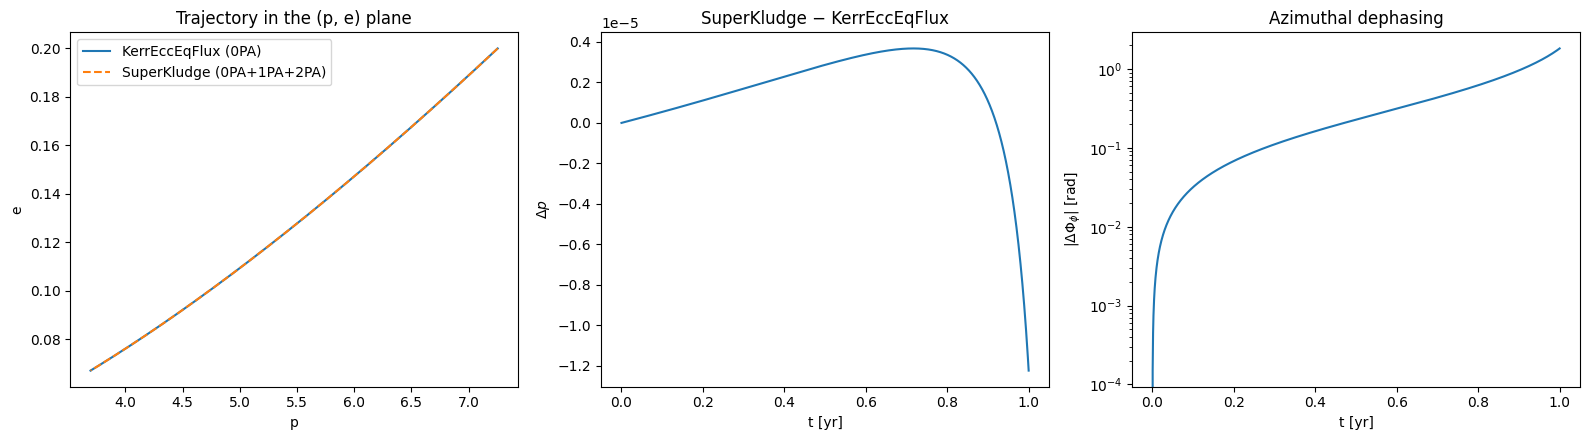

In [6]:
t_c = np.linspace(max(t_k[0], t_sk[0]), min(t_k[-2], t_sk[-2]), 2000)

#CubicSpline is used to interpolate the trajectories to a common time grid for comparison.
# basically we get our values as grid points and then interpolate them to a common time grid for comparison.

dp = CubicSpline(t_sk, p_sk)(t_c) - CubicSpline(t_k, p_k)(t_c)
dphi = CubicSpline(t_sk, Phi_phi_sk)(t_c) - CubicSpline(t_k, Phi_phi_k)(t_c)

fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))
axs[0].plot(p_k, e_k, label="KerrEccEqFlux (0PA)")
axs[0].plot(p_sk, e_sk, "--", label="SuperKludge (0PA+1PA+2PA)")
axs[0].set(xlabel="p", ylabel="e", title="Trajectory in the (p, e) plane")
axs[0].legend()
axs[1].plot(t_c / YRSID_SI, dp)
axs[1].set(xlabel="t [yr]", ylabel=r"$\Delta p$", title="SuperKludge − KerrEccEqFlux")
axs[2].plot(t_c / YRSID_SI, np.abs(dphi))
axs[2].set(xlabel="t [yr]", ylabel=r"$|\Delta\Phi_\phi|$ [rad]", yscale="log", title="Azimuthal dephasing")
plt.tight_layout()
plt.show()

### 4.3 Checking whether an inspiral plunges

Before sampling or computing a Fisher matrix (Fisher are unstable if it is plunging), it is worth checking whether a chosen $p_0$ plunges within the observation time. The helper below does this. It compares $p_0$ with the $p_0$ that gives a plunge after exactly `T_obs` (from `get_p_at_t`), and reports how close the final point gets to the separatrix. It works for both flux classes: pass `add_args` for SuperKludge and nothing for `KerrEccEqFlux`.

In [7]:
def check_inspiral(traj, m1, m2, a, p0, e0, x0=1.0, add_args=(), T_obs=1.0):
    '''
    Check whether an inspiral starting at p0 reaches the separatrix within T_obs years.
    `traj` is an EMRIInspiral instance; `add_args` are the model's extra arguments (empty for KerrEccEqFlux).
    '''
    add_args = list(add_args)
    out = traj(m1, m2, a, p0, e0, x0, *add_args, T=T_obs)
    t_traj, p_traj, e_traj = out[0], out[1], out[2]

    p_plunge = get_p_at_t(traj, T_obs, [m1, m2, a, e0, x0, *add_args])
    p_sep = get_separatrix(a, e_traj[-1], x0)

    print(f"p0 giving a plunge after exactly {T_obs} yr : {p_plunge:.4f}")
    print(f"chosen p0                                : {p0:.4f}")
    if p0 < p_plunge:
        print(f"-> plunges after {t_traj[-1] / YRSID_SI:.4f} yr (before T_obs). Expect instabilities near the end.")
    else:
        print("-> does not plunge within T_obs.")
    print(f"final p = {p_traj[-1]:.4f}, separatrix = {p_sep:.4f}, distance = {abs(p_sep - p_traj[-1]):.4f}")
    print(f"final e = {e_traj[-1]:.4f}")

check_inspiral(traj_kerr, m1, m2, a, p0, e0, x0, T_obs=T)
print()
check_inspiral(traj_sk, m1, m2, a, p0, e0, x0, add_args=add_args, T_obs=T)

p0 giving a plunge after exactly 1.0 yr : 7.1541
chosen p0                                : 7.2541
-> does not plunge within T_obs.
final p = 3.6961, separatrix = 2.3758, distance = 1.3203
final e = 0.0670

p0 giving a plunge after exactly 1.0 yr : 7.1544
chosen p0                                : 7.2541
-> does not plunge within T_obs.
final p = 3.6961, separatrix = 2.3758, distance = 1.3203
final e = 0.0670


## Play with different setting to get a sense of how these parameters work.
- Try using higher mass ratio, m1= 1e6 and m2 = 1e3. In that case, the higher order PA terms are more dominant and depahsing is much larger. 

- increase primary mass to 0.98 and see the difference etc...

## 5. Waveforms

`SuperKludgeWaveform` (in `src/few/waveform/waveform.py`) is built exactly like `FastKerrEccentricEquatorialFlux`: Kerr eccentric-equatorial amplitude interpolation (`AmpInterpKerrEccEq`), mode selection, and interpolated mode summation. The only difference is that the inspiral module uses `func=SuperKludgeFlux`. Any `add_args` you pass are forwarded to the trajectory. The amplitudes remain adiabatic, so all post-adiabatic and deviation effects enter through the phases. This is a good enough as we mostly concern ourselves with the change in phase

Useful constructor keyword arguments (passed through `GenerateEMRIWaveform`):

| kwarg | Meaning |
|---|---|
| `inspiral_kwargs` | e.g. `{"err": 1e-11, "max_step_size": ...}`, forwarded to `EMRIInspiral`. Do not set `func`; it is fixed to `SuperKludgeFlux`. |
| `sum_kwargs` | e.g. `{"pad_output": True}` zero-pads the output to the full length `T/dt` if the source plunges earlier. Useful for optimization and sampling as there can be lenght mismatch if it plunges earlier. `{"output_type": "fd"}` gives a frequency-domain output. |
| `mode_selector_kwargs` | e.g. `{"mode_selection_threshold": 1e-5}`, or `{"mode_selection_type": "neural"}` |
| `force_backend` | `"cpu"` or `"cuda12x"`|


In [ ]:
sum_kwargs = {"pad_output": True}
inspiral_kwargs = {"err": 1e-11, "max_step_size": max_step_size} # max_step_size step in seconds

sk_wave = GenerateEMRIWaveform(
    SuperKludgeWaveform,
    inspiral_kwargs=inspiral_kwargs,
    sum_kwargs=sum_kwargs,
    return_list=True,  # -> [h_plus, h_cross]
)

T_wave = 1  # 1 [yr]
p0_wave = get_p_at_t(traj_sk, T_wave, [m1, m2, a, e0, x0, *add_args]) + 0.1
# this will ensure that the inspiral does not plunge within T_wave, 
# so that we can generate a waveform for the full duration

params = [m1, m2, a, p0_wave, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

start = time.time()
h_sk = sk_wave(*params, *add_args, T=T_wave, dt=dt)
print(f"waveform generated in {time.time() - start:.1f} s, {len(h_sk[0])} samples") 


waveform generated in 30.7 s, 3155815 samples


In [ ]:
start = time.time()
h_sk = sk_wave(*params, *add_args, T=T_wave, dt=dt)
print(f"waveform generated in {time.time() - start:.1f} s, {len(h_sk[0])} samples") #first waveform takes a lot of time
#i think i am not using the GPU now, otherwise, it should take less than a seoncd to generate the waveform

waveform generated in 19.8 s, 3155815 samples


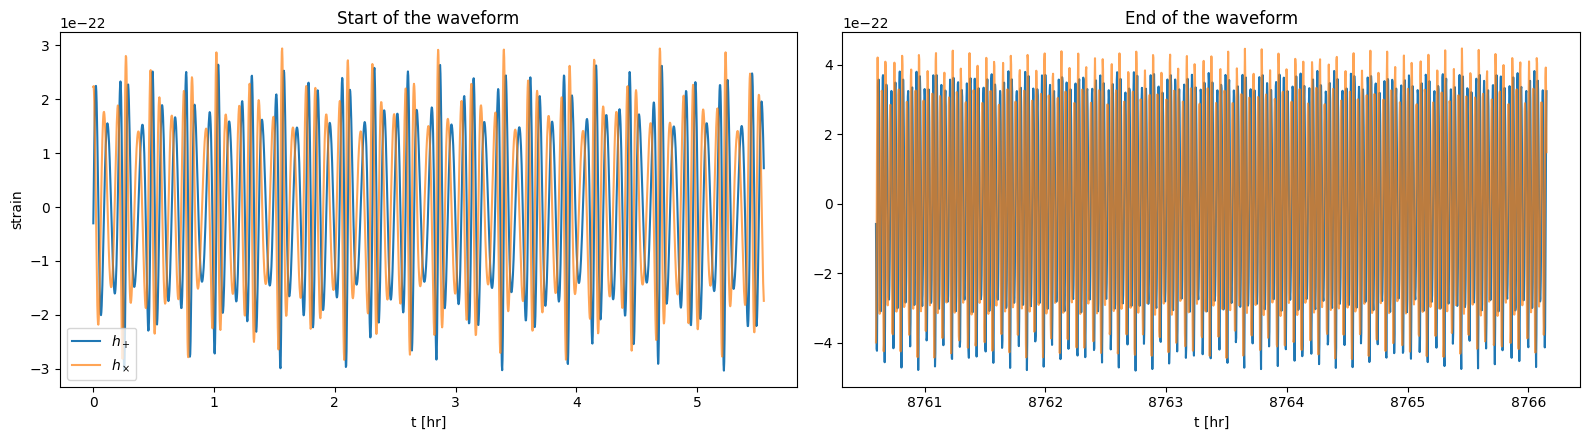

In [9]:
t_wave = np.arange(len(h_sk[0])) * dt

fig, axs = plt.subplots(1, 2, figsize=(16, 4.5))
axs[0].plot(t_wave[:2000] / 3600, h_sk[0][:2000], label=r"$h_+$")
axs[0].plot(t_wave[:2000] / 3600, h_sk[1][:2000], label=r"$h_\times$", alpha=0.7)
axs[0].set(xlabel="t [hr]", ylabel="strain", title="Start of the waveform")
axs[1].plot(t_wave[-2000:] / 3600, h_sk[0][-2000:], label=r"$h_+$")
axs[1].plot(t_wave[-2000:] / 3600, h_sk[1][-2000:], label=r"$h_\times$", alpha=0.7)
axs[1].set(xlabel="t [hr]", title="End of the waveform")
axs[0].legend()
plt.tight_layout()
plt.show()

### 5.1 Comparing waveforms: `KerrEccEqFlux` vs SuperKludge

`get_mismatch(h1, h2)` returns $1 - \langle h_1 | h_2\rangle / \sqrt{\langle h_1|h_1\rangle\langle h_2|h_2\rangle}$ with a flat (white-noise) inner product. It is a quick measure of how distinguishable two waveforms are. It is not a substitute for a proper LISA-noise-weighted analysis.

mismatch SuperKludge vs KerrEccEqFlux: 0.5760686279495435


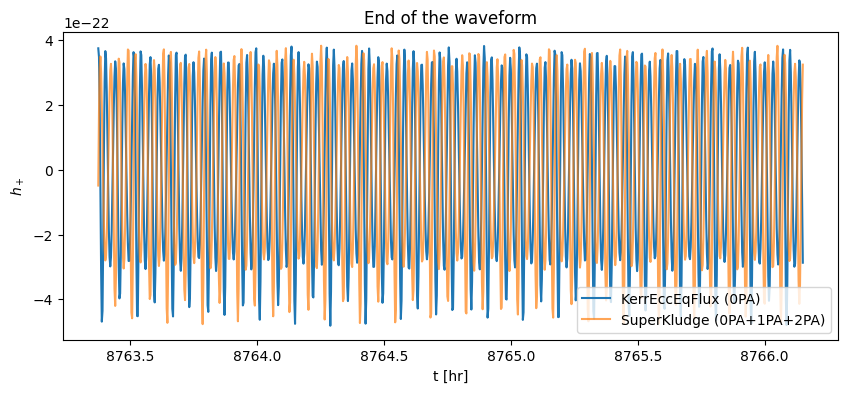

In [10]:
kerr_wave = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux,
    inspiral_kwargs=inspiral_kwargs,
    sum_kwargs=sum_kwargs,
    return_list=True,
)
h_kerr = kerr_wave(*params, T=T_wave, dt=dt)

# waveforms can differ in length if one plunges earlier; compare over the common part
n = min(len(h_sk[0]), len(h_kerr[0]))
print("mismatch SuperKludge vs KerrEccEqFlux:", get_mismatch(h_sk[0][:n], h_kerr[0][:n]))

plt.figure(figsize=(10, 4))
plt.plot(t_wave[-1000:] / 3600, h_kerr[0][-1000:], label="KerrEccEqFlux (0PA)")
plt.plot(t_wave[-1000:] / 3600, h_sk[0][-1000:], label="SuperKludge (0PA+1PA+2PA)", alpha=0.7)
plt.xlabel("t [hr]"); plt.ylabel(r"$h_+$"); plt.title("End of the waveform")
plt.legend(); plt.show()

In [ ]:
#play with different parameters to see how the waveform changes, e.g. change the spin, eccentricity, etc.
# also plot the difference and the mismatch between the two waveforms.

## Summary

* `GenerateEMRIWaveform(SuperKludgeWaveform, ...)` produces detector-frame waveforms. Call it with the 14 EMRI parameters followed by the SuperKludge `add_args`.
* `SuperKludgeFlux` = `KerrEccEqFlux` (0PA Teukolsky fluxes) + PN-approximated 1PA/2PA terms + optional deviation terms. With all flags off it reduces to `KerrEccEqFlux`.
* `add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA, deviation_included, C_p, C_e, del_0_p, del_0_e]`. Keep `evolve_primary = False`. In this notebook, `deviation_included = False`.
* SuperKludge trajectories return 9 arrays (the last two are $\delta m_1$ and $\delta a$). Use `[:7]` if you only need the standard outputs.
* Use `get_p_at_t` (with the same `add_args`) to pick $p_0$ for a given observation time, and `get_separatrix` / `check_inspiral` to check the plunge.

Next: `deviation_models.ipynb` (deviation parameters, Response Wrapper, dephasing and Fisher/bias studies) 